In [1]:
import joblib
import pandas as pd
import shap

In [2]:
model = joblib.load(
    "heart_disease_random_forest_model.pkl"
)

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [3]:
patient = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "chest_pain_type": 4,
    "resting_bp_s": 140,
    "cholesterol": 250,
    "fasting_blood_sugar": 0,
    "resting_ecg": 0,
    "max_heart_rate": 150,
    "exercise_angina": 0,
    "oldpeak": 1.2,
    "ST_slope": 2
}])

patient

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope
0,55,1,4,140,250,0,0,150,0,1.2,2


In [4]:
prediction = model.predict(patient)[0]

probability = model.predict_proba(patient)[0][1]

print("Prediction:", prediction)
print("Probability:", f"{probability:.2%}")

Prediction: 1.0
Probability: 74.52%


In [5]:
print("Pipeline steps:")
print(model.named_steps)

Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'resting_bp_s', 'cholesterol',
                                  'max_heart_rate', 'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'chest_pain_type',
                                  'fasting_blood_sugar', 'resting_ecg',
                                  'exercise_angina', 'ST_slope'])]), 'model': Random

In [6]:
print("Step names:")
print(model.named_steps.keys())

Step names:
dict_keys(['preprocessor', 'model'])


In [7]:
# Get the preprocessing and Random Forest steps
preprocessor = model.named_steps["preprocessor"]
rf_model = model.named_steps["model"]

# Transform the patient data using the same preprocessing
patient_transformed = preprocessor.transform(patient)

print("Transformed patient shape:", patient_transformed.shape)

Transformed patient shape: (1, 22)


In [8]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("Feature names:")
print(feature_names)

Number of features: 22
Feature names:
['num__age' 'num__resting_bp_s' 'num__cholesterol' 'num__max_heart_rate'
 'num__oldpeak' 'cat__sex_0.0' 'cat__sex_1.0' 'cat__chest_pain_type_1.0'
 'cat__chest_pain_type_2.0' 'cat__chest_pain_type_3.0'
 'cat__chest_pain_type_4.0' 'cat__fasting_blood_sugar_0.0'
 'cat__fasting_blood_sugar_1.0' 'cat__resting_ecg_0.0'
 'cat__resting_ecg_1.0' 'cat__resting_ecg_2.0' 'cat__exercise_angina_0.0'
 'cat__exercise_angina_1.0' 'cat__ST_slope_0.0' 'cat__ST_slope_1.0'
 'cat__ST_slope_2.0' 'cat__ST_slope_3.0']


In [9]:
# Create SHAP explainer for the Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(patient_transformed)

print("SHAP values calculated successfully.")


SHAP values calculated successfully.


In [10]:
# Get SHAP values for the predicted class
if isinstance(shap_values, list):
    patient_shap = shap_values[1][0]
else:
    patient_shap = shap_values[0, :, 1]

# Create a feature contribution table
shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": patient_shap
})

# Sort by absolute contribution
shap_df["Absolute SHAP"] = shap_df["SHAP Value"].abs()

shap_df = shap_df.sort_values(
    "Absolute SHAP",
    ascending=False
)

print("Top features contributing to this prediction:")
print(shap_df.head(10))

Top features contributing to this prediction:
                     Feature  SHAP Value  Absolute SHAP
19         cat__ST_slope_1.0    0.132750       0.132750
20         cat__ST_slope_2.0    0.088066       0.088066
10  cat__chest_pain_type_4.0    0.069672       0.069672
17  cat__exercise_angina_1.0   -0.044123       0.044123
16  cat__exercise_angina_0.0   -0.042032       0.042032
3        num__max_heart_rate   -0.036146       0.036146
2           num__cholesterol    0.027804       0.027804
5               cat__sex_0.0    0.020642       0.020642
6               cat__sex_1.0    0.020023       0.020023
8   cat__chest_pain_type_2.0    0.017231       0.017231


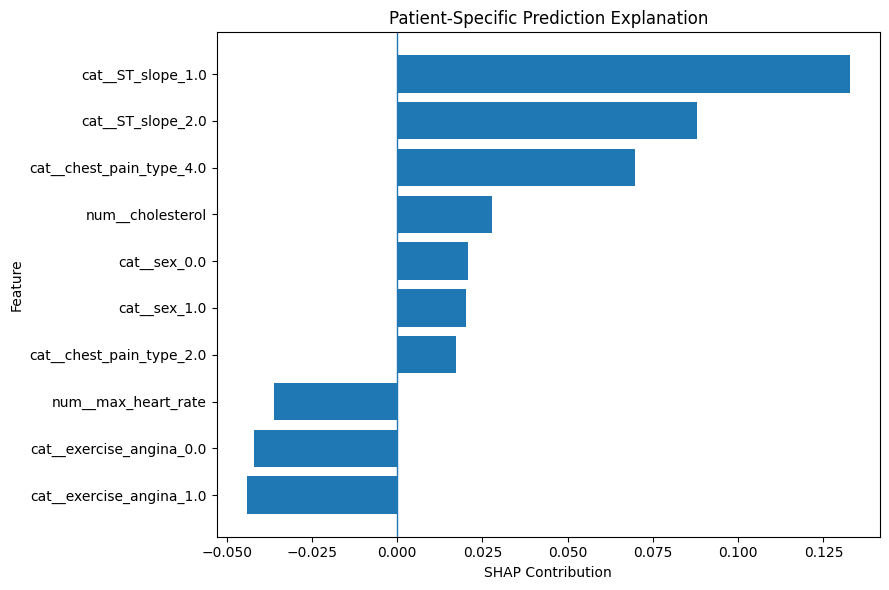

In [11]:
import matplotlib.pyplot as plt

# Select top 10 contributing features
top_features = shap_df.head(10).sort_values("SHAP Value")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["SHAP Value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SHAP Contribution")
plt.ylabel("Feature")
plt.title("Patient-Specific Prediction Explanation")

plt.tight_layout()
plt.show()

In [15]:
feature_name_mapping = {
    "num__age": "Age",
    "num__resting_bp_s": "Resting Blood Pressure",
    "num__cholesterol": "Cholesterol",
    "num__max_heart_rate": "Maximum Heart Rate",
    "num__oldpeak": "Oldpeak",

    "cat__sex_0.0": "Sex: Female",
    "cat__sex_1.0": "Sex: Male",

    "cat__chest_pain_type_1.0": "Chest Pain: Typical Angina",
    "cat__chest_pain_type_2.0": "Chest Pain: Atypical Angina",
    "cat__chest_pain_type_3.0": "Chest Pain: Non-anginal Pain",
    "cat__chest_pain_type_4.0": "Chest Pain: Asymptomatic",

    "cat__fasting_blood_sugar_0.0": "Fasting Blood Sugar: Normal",
    "cat__fasting_blood_sugar_1.0": "Fasting Blood Sugar: High",

    "cat__resting_ecg_0.0": "Resting ECG: Normal",
    "cat__resting_ecg_1.0": "Resting ECG: ST-T Abnormality",
    "cat__resting_ecg_2.0": "Resting ECG: LV Hypertrophy",

    "cat__exercise_angina_0.0": "Exercise Angina: No",
    "cat__exercise_angina_1.0": "Exercise Angina: Yes",

    "cat__ST_slope_1.0": "ST Slope: Upsloping",
    "cat__ST_slope_2.0": "ST Slope: Flat",
    "cat__ST_slope_3.0": "ST Slope: Downsloping"
}

In [16]:
shap_df["Readable Feature"] = (
    shap_df["Feature"]
    .map(feature_name_mapping)
    .fillna(shap_df["Feature"])
)

print(
    shap_df[
        ["Readable Feature", "SHAP Value"]
    ].head(10).to_string(index=False)
)

           Readable Feature  SHAP Value
        ST Slope: Upsloping    0.132750
             ST Slope: Flat    0.088066
   Chest Pain: Asymptomatic    0.069672
       Exercise Angina: Yes   -0.044123
        Exercise Angina: No   -0.042032
         Maximum Heart Rate   -0.036146
                Cholesterol    0.027804
                Sex: Female    0.020642
                  Sex: Male    0.020023
Chest Pain: Atypical Angina    0.017231


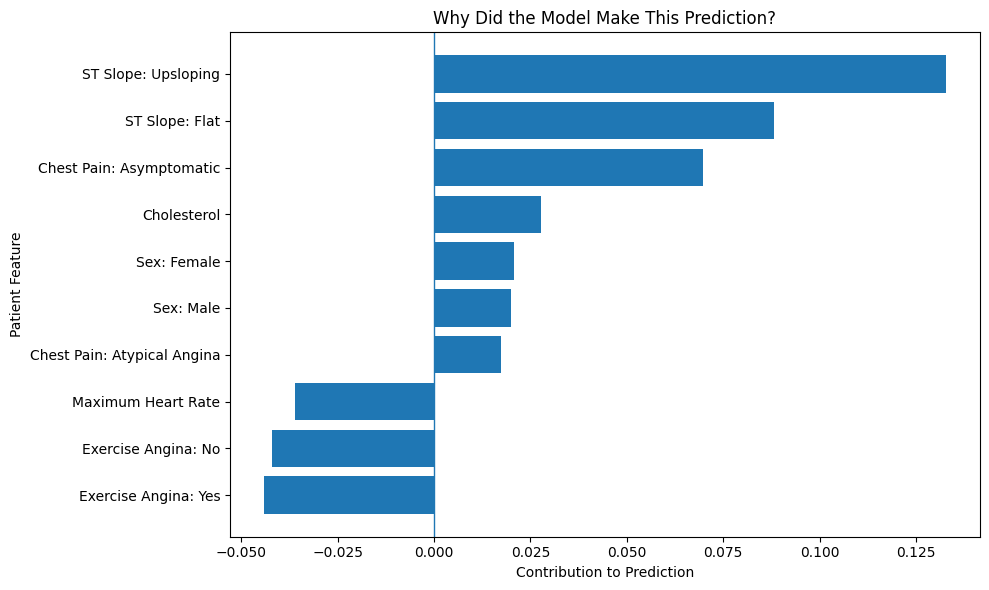

In [17]:
# Create readable SHAP chart

top_features = (
    shap_df
    .head(10)
    .sort_values("SHAP Value")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Readable Feature"],
    top_features["SHAP Value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Contribution to Prediction")
plt.ylabel("Patient Feature")
plt.title("Why Did the Model Make This Prediction?")

plt.tight_layout()
plt.show()